In [ ]:
# ==========================================
# INSTALL & IMPORTS FOR SERESNEXT50 + XAI
# ==========================================

!pip install timm lime shap grad-cam alibi -q

import torch
import torch.nn as nn
import timm
import random
import shap
import cv2

from tqdm import tqdm
from lime import lime_image
from skimage.segmentation import mark_boundaries

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 106.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 10.3 MB/s eta 0:00:00
cuda


In [ ]:
# IMAGE TRANSFORMS (512x512)

IMG_SIZE = 512
BATCH_SIZE = 8
NUM_CLASSES = train_df["DR_ICDR"].nunique()

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [ ]:
# DATASET CLASS
class RetinaDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = int(row["DR_ICDR"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = RetinaDataset(train_df, transform=train_transform)
val_dataset   = RetinaDataset(val_df, transform=val_transform)
test_dataset  = RetinaDataset(test_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1627
Val batches: 204
Test batches: 203


In [ ]:
# SE-RESNEXT50 MODEL

model = timm.create_model(
    "seresnext50_32x4d",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=2,
    factor=0.5
)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/111M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_

In [ ]:
# TRAINING

# USE SMALLER DATA SAMPLE
train_sample_df = train_df.sample(4000, random_state=42)
val_sample_df   = val_df.sample(1000, random_state=42)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 3

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = RetinaDataset(train_sample_df, transform=train_transform)
val_dataset   = RetinaDataset(val_sample_df, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Using reduced dataset for very fast training.")

Using reduced dataset for very fast training.


In [ ]:
# FREEZE EVERYTHING EXCEPT LAST LAYER

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

print("Only final layer is trainable.")

Only final layer is trainable.


In [ ]:
EPOCHS=3

# FAST TRAINING WITH LOSSES SAVED

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

best_val_acc = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # ================= TRAIN =================

    model.train()

    running_train_loss = 0
    train_correct = 0
    train_total = 0

    loop = tqdm(train_loader)

    for images, labels in loop:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / len(train_loader)
    train_acc = train_correct / train_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ================= VALIDATION =================

    model.eval()

    running_val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast():

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = running_val_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), "best_seresnext50_ultrafast.pth")

        print("Best model saved!")

/tmp/ipykernel_9275/3745480239.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
  0%|          | 0/125 [00:00<?, ?it/s]/tmp/ipykernel_9275/3745480239.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 125/125 [04:45<00:00,  2.28s/it]
/tmp/ipykernel_9275/3745480239.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/1
Train Loss: 0.3553
Train Acc : 0.9247
Val Loss  : 0.2774
Val Acc   : 0.9460
Best model saved!


In [ ]:
print(train_losses)
print(val_losses)

print(train_accs)
print(val_accs)

[0.35526817619800566]
[0.27739395946264267]
[0.92475]
[0.946]


In [ ]:
# LOAD BEST ULTRAFAST MODEL

model.load_state_dict(
    torch.load("best_seresnext50_ultrafast.pth")
)

model.eval()

print("Best ultrafast model loaded!")

Best ultrafast model loaded!


In [ ]:
# TEST EVALUATION

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average="macro")
f1_weighted = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", acc)
print("F1 Macro:", f1_macro)
print("F1 Weighted:", f1_weighted)

print(classification_report(all_labels, all_preds))

100%|██████████| 203/203 [02:11<00:00,  1.54it/s]

Accuracy: 0.9190858554663373
F1 Macro: 0.19156742838751206
F1 Weighted: 0.8803345689951141
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1488
           1       0.00      0.00      0.00        23
           2       0.00      0.00      0.00        50
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        52

    accuracy                           0.92      1619
   macro avg       0.18      0.20      0.19      1619
weighted avg       0.84      0.92      0.88      1619




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
for param in model.parameters():
    param.requires_grad = True

XAI TECHS

  0%|          | 0/1000 [00:00<?, ?it/s]

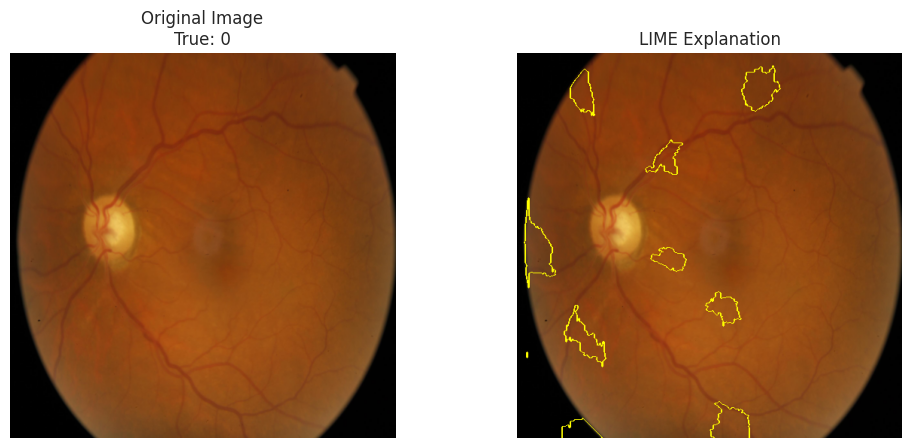

In [ ]:
# LIME EXPLANATION

explainer = lime_image.LimeImageExplainer()

def predict_for_lime(images):

    model.eval()

    batch = []

    for img in images:

        img = cv2.resize(img, (512,512))

        img = torch.tensor(img).permute(2,0,1).float()/255.0

        batch.append(img)

    batch = torch.stack(batch).to(device)

    with torch.no_grad():
        preds = model(batch)

    return torch.softmax(preds, dim=1).cpu().numpy()


sample_idx = random.randint(0, len(test_dataset)-1)

image_tensor, label = test_dataset[sample_idx]

image_np = image_tensor.permute(1,2,0).numpy()

explanation = explainer.explain_instance(
    image_np,
    predict_for_lime,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title(f"Original Image\nTrue: {label}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")

plt.show()

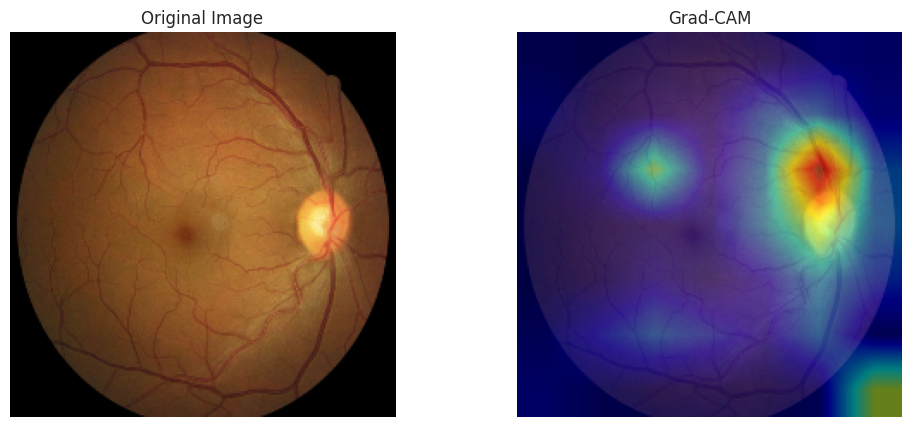

In [ ]:
# XAI 2 — GRAD-CAM

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

sample_img_path = test_df.iloc[0]["image_path"]

img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_img = val_transform(img).unsqueeze(0).to(device)

target_class = int(test_df.iloc[0]["DR_ICDR"])

grayscale_cam = cam(
    input_tensor=input_img,
    targets=[ClassifierOutputTarget(target_class)]
)[0]

rgb_img = img.astype(np.float32) / 255.0
rgb_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

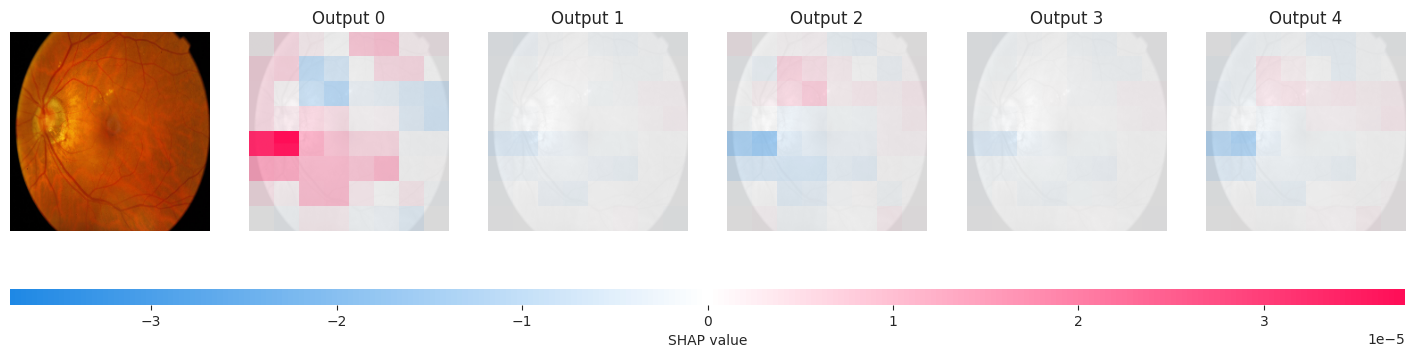

In [ ]:
# XAI 3 — SHAP IMAGE EXPLANATION

import shap

# ==========================================
# PREDICTION FUNCTION
# ==========================================

def predict_for_shap(images):

    model.eval()

    batch = []

    for img in images:

        img = cv2.resize(img, (224,224))

        tensor = torch.tensor(img).permute(2,0,1).float()/255.0

        batch.append(tensor)

    batch = torch.stack(batch).to(device)

    with torch.no_grad():

        outputs = model(batch)

        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

# ==========================================
# LOAD SAMPLE IMAGE

sample_idx = random.randint(0, len(test_df)-1)

img_path = test_df.iloc[sample_idx]["image_path"]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (224,224))

# SHAP IMAGE MASKER

masker = shap.maskers.Image("blur(32,32)", img.shape)

explainer = shap.Explainer(
    predict_for_shap,
    masker
)

# COMPUTE SHAP VALUES

shap_values = explainer(
    np.array([img]),
    max_evals=500,
    batch_size=20
)

# VISUALIZATION

shap.image_plot(shap_values)

In [ ]:
!pip install captum -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 15.4 MB/s eta 0:00:00


Predicted Class: 0


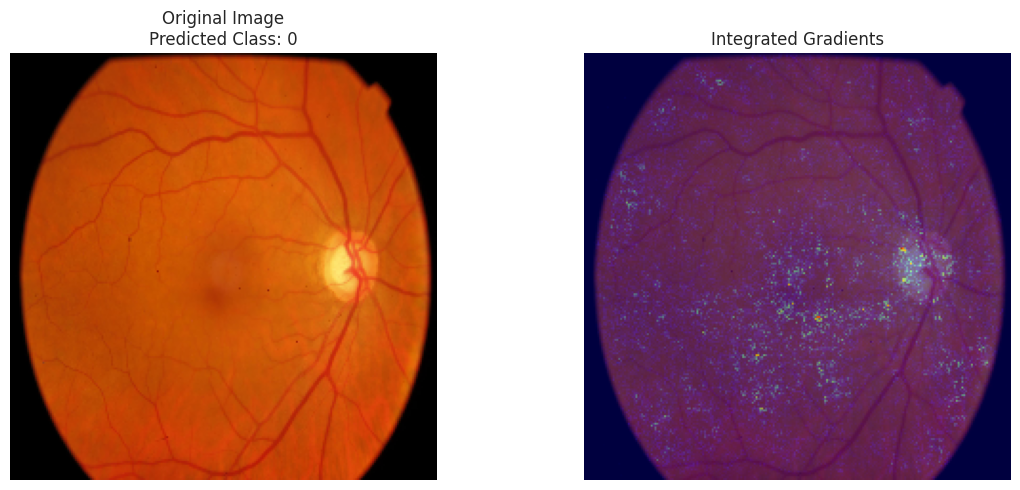

In [ ]:
# XAI 4 — INTEGRATED GRADIENTS

from captum.attr import IntegratedGradients

# LOAD SAMPLE IMAGE

sample_idx = random.randint(0, len(test_df)-1)

img_path = test_df.iloc[sample_idx]["image_path"]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (224,224))

# Convert to tensor
input_tensor = torch.tensor(img).permute(2,0,1).float()/255.0
input_tensor = input_tensor.unsqueeze(0).to(device)

#
# PREDICTION

model.eval()

with torch.no_grad():

    output = model(input_tensor)

    pred_class = torch.argmax(output, dim=1).item()

print("Predicted Class:", pred_class)

# INTEGRATED GRADIENTS

ig = IntegratedGradients(model)

attributions, delta = ig.attribute(
    input_tensor,
    target=pred_class,
    return_convergence_delta=True
)

# PROCESS ATTRIBUTIONS

attr = attributions.squeeze().cpu().detach().numpy()

# Convert CHW -> HWC
attr = np.transpose(attr, (1,2,0))

# Aggregate channels
attr = np.mean(np.abs(attr), axis=2)

# Normalize
attr = (attr - attr.min()) / (
    attr.max() - attr.min() + 1e-8
)

# VISUALIZATION

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Original Image\nPredicted Class: {pred_class}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img)
plt.imshow(attr, cmap='jet', alpha=0.5)
plt.title("Integrated Gradients")
plt.axis("off")

plt.tight_layout()
plt.show()